In [6]:
from pathlib import Path
import jax
import orbax.checkpoint as ocp
from dl4bi.core.train import TrainState
from train_transformer_deeprv import TrainConfig, build_model, build_optimizer
from dl4bi.vae.train_utils import generate_surrogate_decoder

def load_portable_checkpoint(path, config):
    checkpointer = ocp.PyTreeCheckpointer()
    tree = checkpointer.metadata(Path(path).resolve()).item_metadata.tree
    types = (ocp.metadata.ArrayMetadata, ocp.metadata.ScalarMetadata, ocp.metadata.StringMetadata)
    sharding = jax.sharding.SingleDeviceSharding(jax.devices()[0])
    restore_args = jax.tree.map(lambda x: ocp.ArrayRestoreArgs(sharding=sharding) if isinstance(x, ocp.metadata.ArrayMetadata) else ocp.RestoreArgs(), tree, is_leaf=lambda x: isinstance(x, types))
    restored = checkpointer.restore(Path(path).resolve(), item=tree, restore_args=restore_args)["state"]
    model = build_model(config)
    state = TrainState.create(apply_fn=model.apply, params=restored["params"], kwargs=restored["kwargs"], tx=build_optimizer(config))
    return model, state.replace(step=restored["step"], opt_state=restored["opt_state"])

In [ ]:
checkpoint = Path("/Users/keynestay/Desktop/dl4bi/SOAYSHEEP/transformer_deeprv_test/model.ckpt")
config = TrainConfig()
model, state = load_portable_checkpoint(checkpoint, config)
decoder = generate_surrogate_decoder(state, model)

print("Device:", jax.devices())
print("Loaded Training Step:", int(state.step))

Device: [CpuDevice(id=0)]
Loaded Training Step: 100000


In [9]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random
from dl4bi_sps.kernels import rbf

m = 128
num_draws = 16
lengthscale = 1.0
key_s, key_z = random.split(random.key(42))

s = random.uniform(key_s, (m, 1), minval=1.0, maxval=5.0)
K = rbf(s, s, 1.0, lengthscale) + config.jitter * jnp.eye(m)
z = random.normal(key_z, (num_draws, m))
mask = jnp.ones((num_draws, m), dtype=bool)

f_deeprv = decoder(z, jnp.array([lengthscale]), s=s, K=K, mask=mask).squeeze(-1)
f_deeprv.block_until_ready()
f_exact = z @ jnp.linalg.cholesky(K).T

mse = jnp.mean((f_deeprv - f_exact) ** 2)
correlation = jnp.corrcoef(f_deeprv.flatten(), f_exact.flatten())[0, 1]

print("DeepRV Shape:", f_deeprv.shape)
print("All Values Finite:", bool(jnp.all(jnp.isfinite(f_deeprv))))
print("Mean Squared Error:", float(mse))
print("Correlation:", float(correlation))

assert f_deeprv.shape == (num_draws, m)
assert jnp.all(jnp.isfinite(f_deeprv))

DeepRV Shape: (16, 128)
All Values Finite: True
Mean Squared Error: 0.27005672454833984
Correlation: 0.8449320197105408


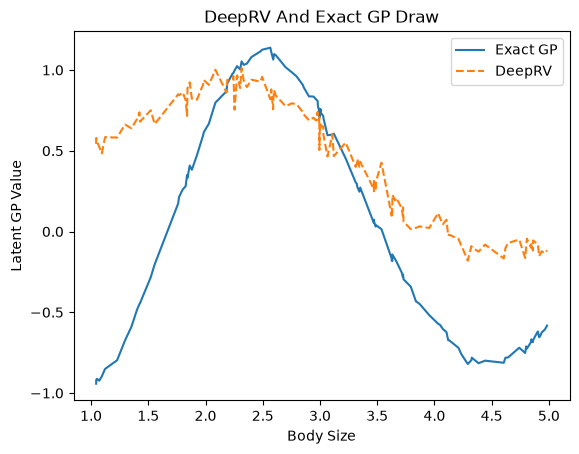

In [10]:
order = jnp.argsort(s[:, 0])

plt.plot(s[order, 0], f_exact[0, order], label="Exact GP")
plt.plot(s[order, 0], f_deeprv[0, order], "--", label="DeepRV")
plt.xlabel("Body Size")
plt.ylabel("Latent GP Value")
plt.title("DeepRV And Exact GP Draw")
plt.legend()
plt.show()